In [1]:
import yaml as yml
import pandas as pd
import re
from emu_renewal.inputs import BASE_PATH
from emu_renewal.outputs import get_table_df_from_priors_dict, plot_beta_priors, plot_progress_priors
from IPython.display import Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")

In [2]:
loaded_priors = yml.safe_load(open(BASE_PATH / "emu_renewal/priors.yml", "r"))

In [3]:
col_widths = '{tbl-colwidths="[14, 8, 8, 70]"}'
durations_df = get_table_df_from_priors_dict(pd.DataFrame.from_dict(loaded_priors["durations"]))
caption = "\n: Parameters and supporting evidence to time period priors. "
Markdown(durations_df.to_markdown() + caption + col_widths)

|                                                        |   Mean |   SD | Evidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|:-------------------------------------------------------|-------:|-----:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Generation time mean (days)                            |   4.5  |  0.5 | Our preferred evidence for quantifying the generation interval come from analyses of transmission pairs that has been estimated in multiple different contexts for SARS-CoV-2.[@chen2022; @ganyani2020] Early case-contact data at the origin of the pandemic in Wuhan estimated a mean of around seven days prior to the implementation of population-wide public health and social measures such as contact tracing and movement restrictions. This led to a contraction of the mean generation interval to around four to five days after these interventions were implemented.[@chen2022] These findings are consistent with estimates from early 2020 from Tianjin, China and Singapore, which estimated generation intervals of around four and five days, respectively.[@ganyani2020] Estimates of the serial interval should be applicable to estimating the generation interval if the epidemic is not changing sufficiently rapidly to result in differences in the incubation period between infectors and infectees [@chen2022]. Estimates of the serial interval from Germany[@anderheiden2022] and Spain[@delaguilamejia2022] fell in a similar range as to the generation interval estimates we use. |
| Generation time standard deviation (days)              |   2.5  |  0.5 | For the standard deviation of the generation interval, we used the same sources of evidence as for the mean.[@chen2022; @ganyani2020] The standard deviation estiamtes were typically in the range of two to four days for early Wuhan [@chen2022] and 1.5 to 2.5 days from Tianjin and Singapore.[@ganyani2020]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Infection to reporting mean (days)                     |   8    |  0.5 | This delay incorporates the incubation period and the time from symptom onset to presentation to the health care system. The incubation period for COVID-19 has been estimated at five to seven days. We have previously estimated the delay from symptom onset to notification to be four days in the Australian context.[@trauer2024; @golding2023]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| Infection to reporting standard deviation (days)       |   3    |  0.5 | Our previous estimate of four days for the time to reporting from symptom onset[@trauer2024] was associated with a standard deviation of two days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| Infection to death mean (days)                         |  20.5  |  5   | A meta-analysis of studies from China quantifying the mean duration from symptom onset to death found a mean delay of 15.93 days.[@khalili2020] A study leveraging individual-level data from Hubei, China in combination with early cases outside of China (not included in the meta-analysis) found a mean time from symptom onset to death of 17.8 days.[@verity2020] A cohort study from a north-eastern state of Brazil found a median 19 days from symptom onset to death.[@sousa2020] We considered 17.5 days to be a reasonable estimate for the time from symptom onset to death, which we increased by three days to account for the time from infection to symptom onset.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| Infection to death standard deviation (days)           |   5    |  2.5 | The meta-analysis of studies from China introduced above[@khalili2020] found a range of symptom to death delays of 13.07 to 18.79 days, while the study from China[@verity2020] reported a credible interval of 16.9 to 19.2 days and the study from Brazil an interquartile range of 12 to 23 days.[@sousa2020]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Infection to hospitalisation mean (days)               |   8.6  |  3   | A study from Belgium reported the duration from symptom onset to hospitalisation to be 5.6 days (Table A.2 appears to provide the correct estimate).[@faes2020] Again, we inflated this for an incubation period of three days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| Infection to hospitalisation standard deviation (days) |   5    |  2   | The study from Belgium[@faes2020] above found considerable variation in the time to admission.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| Hospital admission duration (days)                     |  15    |  2.5 | A systematic review that synthesised hospital admission durations found a median stay of 14 days.[@rees2020] Although more studies were identified for China than for other countries, stay length in China appeared longer than for other countries. Another systematic review undertaken later in the pandemic period found similar durations, with a mean individual-level length of stay of 14.49 days.[@alimohamadi2022]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| Hospitalisation to discharge standard deviation (days) |   7.92 |  2.5 | The interquartile range reported in the first systematic review above[@rees2020] was ten to 19 days, while the individual-level standard deviation identified in the later systematic review above[@alimohamadi2022] was 7.92 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
: Parameters and supporting evidence to time period priors. {tbl-colwidths="[14, 8, 8, 70]"}

In [4]:
from numpyro import distributions as dist
import numpy as np
from plotly import graph_objects as go
from plotly.subplots import make_subplots

In [5]:
duration_priors = {
    k: dist.TruncatedNormal(v["mean"], v["sd"], low=1.0, high=v["mean"] * 2.5) 
    for k, v in loaded_priors["durations"].items()
}

In [6]:
progress_priors = {k: v for k, v in duration_priors.items() if "gen" not in k and "report" not in k}

In [7]:
import matplotlib.pyplot as plt

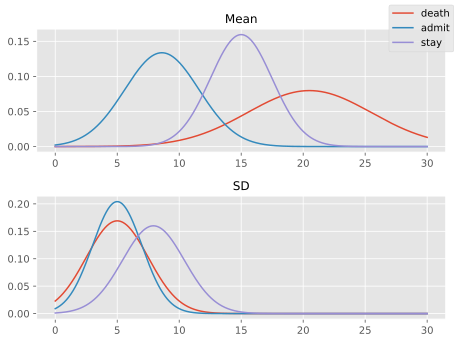

In [8]:
#| fig-cap: "Progression duration prior distributions"
plot_progress_priors(progress_priors)

In [9]:
betas_df = get_table_df_from_priors_dict(pd.DataFrame.from_dict(loaded_priors["beta"]))
caption = "\n: Parameters and supporting evidence to beta-distributed priors. "
Markdown(betas_df.to_markdown() + caption + col_widths)

|                                      |   Alpha |   Beta | Evidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
|:-------------------------------------|--------:|-------:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Case detection proportion            |    5    |  10    | An early analysis from France of the proportion of cases detected estimated that 38% (95% confidence interval 35 to 44%) of cases were detected.[@pullano2020] This is consistent with our estimate that one in two to six cases were detected from the early stages of Australia's Omicron outbreak.[@trauer2024] Nevertheless, this quantity is difficult to determine with confidence and is likely highly context-dependent, hence our broad prior.                                                                                                                                                                 |
| Infection hospitalisation proportion |    6.78 | 186.64 | This quantity was estimated to be 3.39% (credible interval 2.79 to 3.97%) from officially reported data in England prior to the marked declines that occurred as population-wide vaccination was rolled out.[@ward2024]                                                                                                                                                                                                                                                                                                                                                                                                 |
| Infection fatality proportion        |    7.9  | 992.1  | An analysis that integrated serosurveillance with age-specific death rates from 45 countries estimated an infection fatality rate of 0.79% (credible interval 0.68 to 0.92%) for the reference population of France, [@odriscoll2021] which would be expected to vary considerably by population age structure. Other groups have found similarly variable estimates using a combination of modelling and serosurvey results, including an overall IFR estimated at 0.49 to 2.53%.[@brazeau2022] Our prior estimate is relatively broadly distributed and so should be applicable to a range of higher income settings. |
| Cross immunity                       |   10    |  10    | A meta-analysis found that protection against re-infection declined with time and varied with the variant considered, but was estimated at 78.6% (95% uncertainty interval 49.8 to 93.6%).[@covidforecasting2023] Our previous analysis of Australia's epidemic rapid succession of Omicron waves found high levels of immune escape.[@trauer2024]                                                                                                                                                                                                                                                                      |
: Parameters and supporting evidence to beta-distributed priors. {tbl-colwidths="[14, 8, 8, 70]"}

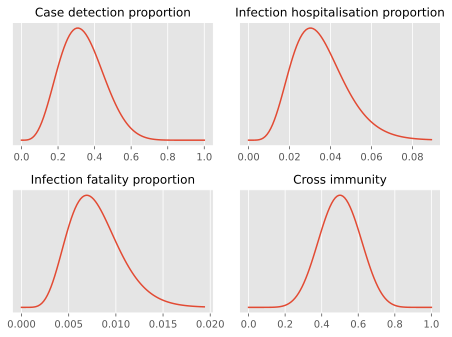

In [10]:
#| fig-cap: "Illustration of beta prior distributions"
plot_beta_priors(loaded_priors)